# Frozen-model external test: new person
Run from the repository root or `main_notebooks/`. The checkpoint, left/right thresholds and **single look-ahead policy** below are fixed before reading test outcomes. No training, validation split fallback or threshold optimization takes place here.

The CSVs already contain the required IMU columns. To score events, each CSV must have a reviewed adjacent `.txt`: exactly one global, zero-based second-tap frame per positive `segment_index` (`, 1` left / `, 2` right); an empty file for every negative recording. The tool `./.venv/bin/python tools/auto_label_imu.py data_miguel_validation/valid_data` can **propose** labels, but review and correct its output before using it as ground truth. Rerunning that tool overwrites edits. Missing labels cause an explicit error, never an implicit negative label.

To omit a known-bad collection session without editing raw recordings or shifting label frames, add its CSV basename, `segment_index`, and a reason to `data/session_exclusions.csv`. The training loader and this notebook consume the same registry and export the applied exclusions.

The repository's `model.step()` is not equivalent to its trained `forward()`. This notebook uses causal full-recording `forward()` in eval mode and an online-causal alarm extraction: only probabilities available by each alarm-emission frame are used. The exported device implementation must eventually pass a separate batch-vs-step equivalence test.

In [1]:
from pathlib import Path
import hashlib
import json
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

ROOT = Path.cwd().resolve()
if not (ROOT / 'tap_recognition').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tap_recognition').is_dir(), 'Run from repository root or main_notebooks/'
sys.path.insert(0, str(ROOT))
from tap_recognition.dataset import RecordedIMUDataset, load_session_exclusions, load_trigger_events
from tap_recognition.model import CausalCNNGRU
from tap_recognition.physics import IMUSimulator
from tap_recognition.recording import IMU_COLUMNS, LabelParams, estimate_sample_rate_hz
from notebooks_analysis.state_reset_analysis import overlap_stream_logits

RUN_DIR = ROOT / 'testing_checkpoints/20260925_112046'
TEST_DIR = ROOT / 'data_miguel_validation/valid_data'
SESSION_EXCLUSIONS_FILE = ROOT / 'data/session_exclusions.csv'
LEFT_THRESHOLD = 0.66   # Frozen max_f1 threshold selected on the OLD validation recordings.
RIGHT_THRESHOLD = 0.74
LOOK_AHEAD_FRAMES = 12  # One policy per run: 12 frames at 100 Hz. Set 0 for instant.
REFRACTORY_SEC = 0.50
EARLY_ALLOWANCE_FRAMES = 1  # An alarm 2 frames early is an FP, not a TP.
MAX_LATE_FRAMES = 30
DEADLINES = (5, 10, 15, 20, 30)
torch.set_num_threads(2)
assert TEST_DIR.is_dir() and 0 < LEFT_THRESHOLD < 1 and 0 < RIGHT_THRESHOLD < 1
session_exclusions = (load_session_exclusions(SESSION_EXCLUSIONS_FILE)
                      if SESSION_EXCLUSIONS_FILE.is_file() else [])
excluded_by_file = {}
for exclusion in session_exclusions:
    excluded_by_file.setdefault(exclusion.source_file, set()).add(exclusion.segment_index)
exclusions_sha256 = (hashlib.sha256(SESSION_EXCLUSIONS_FILE.read_bytes()).hexdigest()
                     if SESSION_EXCLUSIONS_FILE.is_file() else None)
ckpt = torch.load(RUN_DIR / 'best.pt', map_location='cpu', weights_only=True)
train_cfg = ckpt['train_config']
assert train_cfg['data']['mode'] == 'recorded'
model_cfg = dict(ckpt['model_config'])
model_cfg['dilations'] = tuple(model_cfg['dilations'])
model = CausalCNNGRU(**model_cfg).eval()
model.load_state_dict(ckpt['model_state'])
checkpoint_sha256 = hashlib.sha256((RUN_DIR / 'best.pt').read_bytes()).hexdigest()
settings = pd.DataFrame([dict(checkpoint=str(RUN_DIR / 'best.pt'), checkpoint_epoch=ckpt['epoch'],
                              checkpoint_sha256=checkpoint_sha256, test_dir=str(TEST_DIR),
                              left_threshold=LEFT_THRESHOLD, right_threshold=RIGHT_THRESHOLD,
                              look_ahead_frames=LOOK_AHEAD_FRAMES, refractory_sec=REFRACTORY_SEC,
                              early_allowance_frames=EARLY_ALLOWANCE_FRAMES, max_late_frames=MAX_LATE_FRAMES,
                              highpass=train_cfg['data']['highpass'], window_samples=train_cfg['data']['window_samples'],
                              session_exclusions_file=str(SESSION_EXCLUSIONS_FILE),
                              session_exclusions_sha256=exclusions_sha256,
                              declared_session_exclusions=len(session_exclusions),
                              evaluation_design='frozen_external_test')])
settings

,checkpoint,checkpoint_epoch,checkpoint_sha256,test_dir,left_threshold,right_threshold,look_ahead_frames,refractory_sec,early_allowance_frames,max_late_frames,highpass,window_samples,evaluation_design
0,/home/aprohack/desktop/work/tap-project/projec...,21,6ffe3a01ef60c8eacf7976e3bc89a2dc461b352de6a00f...,/home/aprohack/desktop/work/tap-project/projec...,0.66,0.74,12,0.5,1,30,True,300,frozen_external_test


## 1. Audit labels before scoring
The action/side comes from the filename; labels come **only** from the `.txt`. A missing sidecar is never treated as a negative recording. Positive segments with missing second taps also fail the next validation cell.

In [2]:
def expected_class(filename):
    name = filename.lower()
    if 'knock_twice_left' in name: return 1
    if 'knock_twice_right' in name: return 2
    if 'knock_twice' in name: raise ValueError(f'Unknown double-tap side: {filename}')
    return 0

def recording_type(filename):
    tokens = Path(filename).stem.split('_')
    assert len(tokens) >= 5 and tokens[0].lower() == 'imu', filename
    action = '_'.join(tokens[2:-2])
    return 'knock_twice' if action.startswith('knock_twice') else action

csv_files = sorted(TEST_DIR.glob('*.csv'))  # Excludes :Zone.Identifier files.
assert csv_files, f'No CSV recordings in {TEST_DIR}'
label_audit = pd.DataFrame([dict(file=p.name, type=recording_type(p.name),
                                 expected_class=expected_class(p.name),
                                 sidecar_exists=p.with_suffix('.txt').is_file(),
                                 n_events=len(load_trigger_events(p.with_suffix('.txt')))
                                 if p.with_suffix('.txt').is_file() else np.nan)
                            for p in csv_files])
print('CSV files:', len(label_audit), '| missing sidecars:', int((~label_audit.sidecar_exists).sum()))
label_audit.groupby(['type', 'expected_class', 'sidecar_exists'], dropna=False).agg(
    files=('file', 'size'), labeled_events=('n_events', 'sum')).reset_index()

CSV files: 37 | missing sidecars: 0


,type,expected_class,sidecar_exists,files,labeled_events
0,adjust_grip,0,True,3,0
1,arbitrary,0,True,3,0
2,knock_once,0,True,3,0
3,knock_twice,1,True,7,140
4,knock_twice,2,True,10,200
5,pick_place,0,True,2,0
6,shake_phone,0,True,7,0
7,switch_hand,0,True,2,0


In [3]:
label_audit  # Inspect exact files; an absent .txt is not an empty negative label.

,file,type,expected_class,sidecar_exists,n_events
0,imu_Miguel_adjust_grip_20260921_172717.csv,adjust_grip,0,True,0
1,imu_Miguel_adjust_grip_20260923_175813.csv,adjust_grip,0,True,0
2,imu_Miguel_adjust_grip_20260924_093759.csv,adjust_grip,0,True,0
3,imu_Miguel_arbitrary_20260921_172305.csv,arbitrary,0,True,0
4,imu_Miguel_arbitrary_20260921_172416.csv,arbitrary,0,True,0
5,imu_Miguel_arbitrary_20260924_093602.csv,arbitrary,0,True,0
6,imu_Miguel_knock_once_20260921_172128.csv,knock_once,0,True,0
7,imu_Miguel_knock_once_20260924_093428.csv,knock_once,0,True,0
8,imu_Miguel_knock_once_20260925_102444.csv,knock_once,0,True,0
9,imu_Miguel_knock_twice_left_20260921_171641.csv,knock_twice,1,True,20


In [4]:
missing = label_audit.loc[~label_audit.sidecar_exists, 'file'].tolist()
if missing:
    raise FileNotFoundError(f'{len(missing)} missing .txt sidecars (e.g. {missing[0]}). '
                            'Generate proposals with tools/auto_label_imu.py, review them, then rerun. '
                            'This external test will not count missing labels as negatives.')
print('Every recording has a sidecar. Checking each positive segment next.')

Every recording has a sidecar. Checking each positive segment next.


In [5]:
recordings, audit_rows, timestamp_gaps, applied_exclusions, manifest = [], [], [], [], []
for path in csv_files:
    df = pd.read_csv(path)
    required = {'timestamp_ms', 'segment_index', 'user_name', 'action_label', *IMU_COLUMNS}
    assert required <= set(df), f'Missing columns in {path.name}: {required - set(df)}'
    assert len(df) > 1 and df.user_name.nunique() == df.action_label.nunique() == 1, path.name
    expected = expected_class(path.name)
    action = '_'.join(path.stem.split('_')[2:-2])
    assert df.action_label.iloc[0] == action, f'Action differs from filename: {path.name}'
    ts = df.timestamp_ms.to_numpy(dtype=np.float64)
    intervals = np.diff(ts)
    fs = estimate_sample_rate_hz(ts)
    expected_dt_ms = 1000 / fs
    gap_mask = intervals > expected_dt_ms * 1.5
    # Normal scheduler jitter is tolerated; pauses/dropped blocks are retained as explicit audit rows.
    assert np.all(intervals > 0), f'Non-increasing timestamps: {path.name}'
    assert np.all(np.abs(intervals[~gap_mask] - expected_dt_ms) <= 1.0), \
        f'Off-rate timestamps outside gaps: {path.name}'
    assert abs(fs - train_cfg['data']['sample_rate']) < .5, f'{path.name}: {fs:.2f} Hz; resampling needed'
    raw = df[IMU_COLUMNS].to_numpy(dtype=np.float32)
    assert np.isfinite(raw).all(), f'Nonfinite IMU values: {path.name}'
    seg = df.segment_index.to_numpy()
    starts = np.r_[0, np.flatnonzero(seg[1:] != seg[:-1]) + 1]
    ends = np.r_[starts[1:], len(df)]
    segment_ids = seg[starts].astype(int)
    indexed_bounds = list(zip(segment_ids.tolist(), starts.tolist(), ends.tolist()))
    assert len(indexed_bounds) == len(np.unique(seg)), f'Repeated noncontiguous segment ID: {path.name}'
    excluded_segments = excluded_by_file.get(path.name, set())
    unknown_exclusions = excluded_segments - set(segment_ids)
    assert not unknown_exclusions, f'{path.name}: unknown excluded segment(s) {sorted(unknown_exclusions)}'
    bounds = [(start, end) for segment_index, start, end in indexed_bounds if segment_index not in excluded_segments]
    excluded_bounds = [(start, end) for segment_index, start, end in indexed_bounds if segment_index in excluded_segments]
    assert bounds, f'{path.name}: all segments are excluded'
    scoring_bounds = []
    for start, end in bounds:
        if scoring_bounds and scoring_bounds[-1][1] == start:
            scoring_bounds[-1] = (scoring_bounds[-1][0], end)
        else:
            scoring_bounds.append((start, end))
    if not excluded_bounds:
        scoring_bounds = [(0, len(df))]
    events = load_trigger_events(path.with_suffix('.txt'))
    assert all(0 <= frame < len(df) and cls in (1, 2) for frame, cls in events), path.name
    for segment_index, start, end in indexed_bounds:
        if segment_index in excluded_segments:
            continue
        local = [(f, c) for f, c in events if start <= f < end]
        assert len(local) <= int(expected > 0), (path.name, start, end, local)
        assert all(c == expected for _, c in local), (path.name, start, end, local)
    scored_events = [(frame, cls) for frame, cls in events
                     if not any(start <= frame < end for start, end in excluded_bounds)]
    for exclusion in session_exclusions:
        if exclusion.source_file == path.name:
            start, end = next((start, end) for segment_index, start, end in indexed_bounds
                              if segment_index == exclusion.segment_index)
            applied_exclusions.append(dict(source_file=path.name, segment_index=exclusion.segment_index,
                                          reason=exclusion.reason, start_frame=start, end_frame=end,
                                          rows=end-start, events_removed=sum(start <= frame < end for frame, _ in events)))
    imu = IMUSimulator(sample_rate=fs).highpass(raw) if train_cfg['data']['highpass'] else raw
    recordings.append(dict(path=path, file=path.name, user=df.user_name.iloc[0],
                           type=recording_type(path.name), action=action, fs=fs, imu=imu,
                           raw=raw, events=scored_events, bounds=bounds,
                           scoring_bounds=scoring_bounds, excluded_bounds=excluded_bounds))
    audit_rows.append(dict(file=path.name, user=df.user_name.iloc[0], type=recording_type(path.name),
                           rows=len(df), minutes=sum(end-start for start, end in bounds)/fs/60,
                           segments=len(indexed_bounds), included_segments=len(bounds),
                           excluded_segments=len(excluded_bounds), events=len(scored_events),
                           excluded_events=len(events)-len(scored_events), fs=fs,
                           timestamp_gap_count=int(gap_mask.sum()),
                           max_interval_ms=float(intervals.max()),
                           max_timestamp_gap_ms=float(intervals[gap_mask].max()) if gap_mask.any() else 0.0,
                           min_segment=int((ends-starts).min()), max_segment=int((ends-starts).max())))
    for frame, gap_ms in zip(np.flatnonzero(gap_mask), intervals[gap_mask]):
        timestamp_gaps.append(dict(file=path.name, gap_after_frame=int(frame),
                                   gap_before_frame=int(frame + 1), gap_ms=float(gap_ms)))
    for source in (path, path.with_suffix('.txt')):
        manifest.append(dict(path=str(source.relative_to(ROOT)),
                             sha256=hashlib.sha256(source.read_bytes()).hexdigest()))
recording_audit = pd.DataFrame(audit_rows)
applied_session_exclusions = pd.DataFrame(applied_exclusions, columns=['source_file', 'segment_index', 'reason',
                                                                    'start_frame', 'end_frame', 'rows', 'events_removed'])
timestamp_gap_audit = pd.DataFrame(timestamp_gaps,
                                    columns=['file', 'gap_after_frame', 'gap_before_frame', 'gap_ms'])
if SESSION_EXCLUSIONS_FILE.is_file():
    manifest.append(dict(path=str(SESSION_EXCLUSIONS_FILE.relative_to(ROOT)), sha256=exclusions_sha256))
test_data_sha256 = hashlib.sha256(json.dumps(sorted(manifest, key=lambda x: x['path']),
                                            sort_keys=True).encode()).hexdigest()
settings = settings.assign(applied_session_exclusions=len(applied_session_exclusions))
print('Reviewed test recordings:', len(recordings), '| annotated taps:', recording_audit.events.sum())
print('Excluded sessions:', len(applied_session_exclusions))
print('Timestamp discontinuities:', len(timestamp_gap_audit),
      '| total active-stream minutes:', f'{recording_audit.minutes.sum():.2f}')
recording_audit.groupby('type').agg(files=('file', 'size'), minutes=('minutes', 'sum'),
                                     segments=('segments', 'sum'), events=('events', 'sum')).reset_index()

Reviewed test recordings: 37 | annotated taps: 340
Timestamp discontinuities: 0 | total active-stream minutes: 37.37


,type,files,minutes,segments,events
0,adjust_grip,3,3.030667,60,0
1,arbitrary,3,3.029167,60,0
2,knock_once,3,3.027000,60,0
3,knock_twice,17,17.170500,340,340
4,pick_place,2,2.020167,40,0
5,shake_phone,7,7.069667,140,0
6,switch_hand,2,2.020000,40,0


In [6]:
recording_audit  # Per-file sampling, segment lengths and reviewed event counts.

,file,user,type,rows,minutes,segments,events,fs,timestamp_gap_count,max_interval_ms,max_timestamp_gap_ms,min_segment,max_segment
0,imu_Miguel_adjust_grip_20260921_172717.csv,Miguel,adjust_grip,6061,1.010167,20,0,100.0,0,10.0,0.0,300,305
1,imu_Miguel_adjust_grip_20260923_175813.csv,Miguel,adjust_grip,6062,1.010333,20,0,100.0,0,10.0,0.0,300,305
2,imu_Miguel_adjust_grip_20260924_093759.csv,Miguel,adjust_grip,6061,1.010167,20,0,100.0,0,10.0,0.0,300,304
3,imu_Miguel_arbitrary_20260921_172305.csv,Miguel,arbitrary,6062,1.010333,20,0,100.0,0,10.0,0.0,301,305
4,imu_Miguel_arbitrary_20260921_172416.csv,Miguel,arbitrary,6055,1.009167,20,0,100.0,0,10.0,0.0,300,305
5,imu_Miguel_arbitrary_20260924_093602.csv,Miguel,arbitrary,6058,1.009667,20,0,100.0,0,10.0,0.0,301,304
6,imu_Miguel_knock_once_20260921_172128.csv,Miguel,knock_once,6049,1.008167,20,0,100.0,0,10.0,0.0,299,304
7,imu_Miguel_knock_once_20260924_093428.csv,Miguel,knock_once,6061,1.010167,20,0,100.0,0,10.0,0.0,300,304
8,imu_Miguel_knock_once_20260925_102444.csv,Miguel,knock_once,6052,1.008667,20,0,100.0,0,10.0,0.0,300,305
9,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,6055,1.009167,20,20,100.0,0,10.0,0.0,301,304


In [7]:
if len(timestamp_gap_audit):
    display(timestamp_gap_audit)
    print('Frame latency and FP/min use active sampled time; the pauses above are excluded from that denominator.')
else:
    print('No timestamp discontinuities larger than 1.5 sample periods.')

No timestamp discontinuities larger than 1.5 sample periods.


## 2. Frozen causal predictions and one alarm policy
The GRU/CNN state persists within a file and resets between files. The filter is applied once per complete recording. Alarm timing is the **emission frame** after look-ahead, not the selected probability peak.

In [8]:
probabilities = {}
with torch.inference_mode():
    for rec in recordings:
        probs = np.zeros((len(rec['imu']), 3), dtype=np.float32)
        probs[:, 0] = 1.0
        for start, end in rec['scoring_bounds']:
            x = torch.from_numpy(rec['imu'][start:end]).unsqueeze(0)
            logits, _ = model(x)
            probs[start:end] = logits[0].softmax(-1).numpy()
        probabilities[rec['file']] = probs
    # Spot-check that chunked causal execution agrees with full forward.
    start, end = recordings[0]['scoring_bounds'][0]
    x = torch.from_numpy(recordings[0]['imu'][start:min(start + 640, end)]).unsqueeze(0)
    reference, _ = model(x)
    chunks = [min(128, x.shape[1]-i) for i in range(0, x.shape[1], 128)]
    torch.testing.assert_close(overlap_stream_logits(model, x, chunks), reference, atol=2e-5, rtol=2e-5)
print('Causal batch/chunk equivalence checked; no trained weights or thresholds changed.')

Causal batch/chunk equivalence checked; no trained weights or thresholds changed.


In [9]:
def emit_alarms_pair(probs, look, refractory, bounds=None):
    thresholds = np.array([LEFT_THRESHOLD, RIGHT_THRESHOLD])
    alarms = []
    for start, end in (bounds or [(0, len(probs))]):
        segment, i, n = probs[start:end], 0, end - start
        while i < n:
            if not np.any(segment[i, 1:] >= thresholds):
                i += 1
                continue
            emission = i + look
            if emission >= n:
                break
            candidate = segment[i:emission+1, 1:]
            eligible = np.where(candidate >= thresholds, candidate, -np.inf)
            offset, side = np.unravel_index(eligible.argmax(), eligible.shape)
            peak, cls = i + int(offset), int(side) + 1
            alarms.append(dict(alarm_frame=start + emission, peak_frame=start + peak, class_id=cls,
                               probability=float(segment[peak, cls])))
            i = max(emission + 1, peak + max(1, refractory))
    return alarms

def match_alarms(truth, alarms, class_aware=True):
    n, m = len(truth), len(alarms)
    if not n or not m: return []
    cost = np.full((n, m+n), 1e6, dtype=float)
    cost[:, m:] = 1e3  # Dummy columns allow unmatched truths.
    for a, (frame, cls) in enumerate(truth):
        for b, alarm in enumerate(alarms):
            delta = alarm['alarm_frame'] - frame
            if (-EARLY_ALLOWANCE_FRAMES <= delta <= MAX_LATE_FRAMES and
                    (not class_aware or cls == alarm['class_id'])):
                cost[a, b] = abs(delta)
    rows, cols = linear_sum_assignment(cost)
    return [(int(a), int(b)) for a, b in zip(rows, cols) if b < m and cost[a, b] < 1e3]

assert not match_alarms([(100, 1)], [dict(alarm_frame=98, class_id=1)])
assert match_alarms([(100, 1)], [dict(alarm_frame=99, class_id=1)]) == [(0, 0)]
assert not match_alarms([(100, 1)], [dict(alarm_frame=100, class_id=2)])
def ratio(a, b): return float(a/b) if b else float('nan')
print('Strict one-to-one matching checked: -2 is FP, wrong side is FP+FN.')

Strict one-to-one matching checked: -2 is FP, wrong side is FP+FN.


## 3. Event-level results: the main test
Each annotation can match at most one emitted alarm of the correct side. Unmatched alarms are FPs, including alarms on negative recordings. An unmatched tap is an FN. Latency statistics are conditional on true positives; deadline recall includes *all* annotated taps.

In [10]:
file_rows, alarm_rows, truth_rows = [], [], []
for rec in recordings:
    file = rec['file']
    predicted = emit_alarms_pair(probabilities[file], LOOK_AHEAD_FRAMES,
                                 round(REFRACTORY_SEC * rec['fs']), rec['scoring_bounds'])
    predicted = [alarm for alarm in predicted if not any(start <= alarm['alarm_frame'] < end
                                                     for start, end in rec['excluded_bounds'])]
    matches = match_alarms(rec['events'], predicted)
    binary_matches = match_alarms(rec['events'], predicted, class_aware=False)
    matched_truth = {i: j for i, j in matches}
    matched_alarm = {j: i for i, j in matches}
    minutes = sum(end-start for start, end in rec['bounds']) / rec['fs'] / 60
    entry = dict(file=file, user=rec['user'], type=rec['type'], action=rec['action'],
                 minutes=minutes, excluded_sessions=len(rec['excluded_bounds']),
                 n_events=len(rec['events']), n_alarms=len(predicted),
                 tp=len(matches), fp=len(predicted)-len(matches), fn=len(rec['events'])-len(matches),
                 binary_tp=len(binary_matches), binary_fp=len(predicted)-len(binary_matches),
                 binary_fn=len(rec['events'])-len(binary_matches))
    for cls, name in ((1, 'left'), (2, 'right')):
        tp = sum(rec['events'][i][1] == cls for i, _ in matches)
        entry.update({f'{name}_tp': tp, f'{name}_fp': sum(a['class_id'] == cls for a in predicted)-tp,
                      f'{name}_fn': sum(c == cls for _, c in rec['events'])-tp})
    assert entry['left_tp'] + entry['right_tp'] == entry['tp']
    entry.update(precision=ratio(entry['tp'], entry['tp']+entry['fp']),
                 recall=ratio(entry['tp'], entry['tp']+entry['fn']),
                 f1=ratio(2*entry['tp'], 2*entry['tp']+entry['fp']+entry['fn']),
                 fp_per_min=ratio(entry['fp'], minutes))
    file_rows.append(entry)
    for i, (frame, cls) in enumerate(rec['events']):
        alarm = predicted[matched_truth[i]] if i in matched_truth else None
        truth_rows.append(dict(file=file, user=rec['user'], type=rec['type'], true_frame=frame,
                               true_class=cls, matched=alarm is not None,
                               alarm_frame=alarm['alarm_frame'] if alarm else np.nan,
                               latency_frames=alarm['alarm_frame']-frame if alarm else np.nan,
                               latency_ms=(alarm['alarm_frame']-frame)/rec['fs']*1000 if alarm else np.nan))
    for j, alarm in enumerate(predicted):
        i = matched_alarm.get(j)
        nearest = min(rec['events'], key=lambda e: abs(e[0]-alarm['alarm_frame'])) if rec['events'] else None
        alarm_rows.append(dict(file=file, user=rec['user'], type=rec['type'], **alarm, matched=i is not None,
                               true_frame=rec['events'][i][0] if i is not None else np.nan,
                               nearest_true_delta=alarm['alarm_frame']-nearest[0] if nearest else np.nan))
file_events = pd.DataFrame(file_rows)
alarm_details = pd.DataFrame(alarm_rows)
truth_events = pd.DataFrame(truth_rows)
file_events[['file', 'user', 'type', 'minutes', 'n_events', 'n_alarms', 'tp', 'fp', 'fn',
             'precision', 'recall', 'f1', 'fp_per_min']]

,file,user,type,minutes,n_events,n_alarms,tp,fp,fn,precision,recall,f1,fp_per_min
0,imu_Miguel_adjust_grip_20260921_172717.csv,Miguel,adjust_grip,1.010167,0,0,0,0,0,NaN,NaN,NaN,0.000000
1,imu_Miguel_adjust_grip_20260923_175813.csv,Miguel,adjust_grip,1.010333,0,0,0,0,0,NaN,NaN,NaN,0.000000
2,imu_Miguel_adjust_grip_20260924_093759.csv,Miguel,adjust_grip,1.010167,0,0,0,0,0,NaN,NaN,NaN,0.000000
3,imu_Miguel_arbitrary_20260921_172305.csv,Miguel,arbitrary,1.010333,0,0,0,0,0,NaN,NaN,NaN,0.000000
4,imu_Miguel_arbitrary_20260921_172416.csv,Miguel,arbitrary,1.009167,0,1,0,1,0,0.000000,NaN,0.000000,0.990917
5,imu_Miguel_arbitrary_20260924_093602.csv,Miguel,arbitrary,1.009667,0,0,0,0,0,NaN,NaN,NaN,0.000000
6,imu_Miguel_knock_once_20260921_172128.csv,Miguel,knock_once,1.008167,0,0,0,0,0,NaN,NaN,NaN,0.000000
7,imu_Miguel_knock_once_20260924_093428.csv,Miguel,knock_once,1.010167,0,0,0,0,0,NaN,NaN,NaN,0.000000
8,imu_Miguel_knock_once_20260925_102444.csv,Miguel,knock_once,1.008667,0,0,0,0,0,NaN,NaN,NaN,0.000000
9,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,1.009167,20,18,18,0,2,1.000000,0.90,0.947368,0.000000


In [11]:
def aggregate_events(group, matched):
    tp, fp, fn = (int(group[key].sum()) for key in ('tp', 'fp', 'fn'))
    bt, bp, bn = (int(group[f'binary_{key}'].sum()) for key in ('tp', 'fp', 'fn'))
    minutes = group.minutes.sum()
    negative = group[group.n_events == 0]
    latencies = matched.loc[matched.matched, 'latency_ms']
    output = dict(recordings=len(group), minutes=minutes, annotated=tp+fn, tp=tp, fp=fp, fn=fn,
                  precision=ratio(tp, tp+fp), recall=ratio(tp, tp+fn),
                  f1=ratio(2*tp, 2*tp+fp+fn), fp_per_min=ratio(fp, minutes),
                  negative_fp_per_min=ratio(negative.fp.sum(), negative.minutes.sum()),
                  binary_f1=ratio(2*bt, 2*bt+bp+bn),
                  mean_latency_ms=latencies.mean(), median_latency_ms=latencies.median(),
                  p90_latency_ms=latencies.quantile(.9),
                  mean_abs_timing_error_ms=latencies.abs().mean())
    for deadline in DEADLINES:
        output[f'recall_lt_{deadline}f'] = ratio(
            ((matched.matched) & (matched.latency_frames < deadline)).sum(), tp+fn)
    return output

event_summary = pd.DataFrame([aggregate_events(file_events, truth_events)])
event_summary[['recordings', 'annotated', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1',
               'fp_per_min', 'negative_fp_per_min', 'binary_f1', 'mean_latency_ms',
               'p90_latency_ms', 'mean_abs_timing_error_ms',
               *[f'recall_lt_{d}f' for d in DEADLINES]]]

,recordings,annotated,tp,fp,fn,precision,recall,f1,fp_per_min,negative_fp_per_min,binary_f1,mean_latency_ms,p90_latency_ms,mean_abs_timing_error_ms,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f
0,37,340,183,44,157,0.806167,0.538235,0.645503,1.177504,1.683446,0.666667,122.677596,150.0,122.677596,0.017647,0.061765,0.464706,0.523529,0.538235


In [12]:
side_rows = []
for cls, name in ((1, 'left'), (2, 'right')):
    tp, fp, fn = (int(file_events[f'{name}_{key}'].sum()) for key in ('tp', 'fp', 'fn'))
    subset = truth_events[truth_events.true_class == cls]
    side_rows.append(dict(side=name, support=tp+fn, tp=tp, fp=fp, fn=fn,
                          precision=ratio(tp, tp+fp), recall=ratio(tp, tp+fn),
                          f1=ratio(2*tp, 2*tp+fp+fn),
                          **{f'recall_lt_{d}f': ratio((subset.matched &
                                                (subset.latency_frames < d)).sum(), len(subset))
                             for d in DEADLINES}))
side_summary = pd.DataFrame(side_rows)
assert side_summary.tp.sum() == event_summary.tp.iloc[0]
side_summary

,side,support,tp,fp,fn,precision,recall,f1,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f
0,left,140,100,27,40,0.787402,0.714286,0.749064,0.014286,0.092857,0.578571,0.685714,0.714286
1,right,200,83,17,117,0.830000,0.415000,0.553333,0.020000,0.040000,0.385000,0.410000,0.415000


In [13]:
type_rows = []
for name, group in file_events.groupby('type'):
    matching = truth_events[truth_events.type == name] if len(truth_events) else truth_events
    type_rows.append(dict(type=name, **aggregate_events(group, matching)))
type_events = pd.DataFrame(type_rows)
type_events[['type', 'recordings', 'minutes', 'annotated', 'tp', 'fp', 'fn',
             'precision', 'recall', 'f1', 'fp_per_min']]

,type,recordings,minutes,annotated,tp,fp,fn,precision,recall,f1,fp_per_min
0,adjust_grip,3,3.030667,0,0,0,0,NaN,NaN,NaN,0.000000
1,arbitrary,3,3.029167,0,0,1,0,0.000000,NaN,0.000000,0.330124
2,knock_once,3,3.027000,0,0,0,0,NaN,NaN,NaN,0.000000
3,knock_twice,17,17.170500,340,183,10,157,0.948187,0.538235,0.686679,0.582394
4,pick_place,2,2.020167,0,0,0,0,NaN,NaN,NaN,0.000000
5,shake_phone,7,7.069667,0,0,32,0,0.000000,NaN,0.000000,4.526380
6,switch_hand,2,2.020000,0,0,1,0,0.000000,NaN,0.000000,0.495050


In [14]:
user_events = pd.DataFrame([dict(user=name, **aggregate_events(group,
                                  truth_events[truth_events.user == name]))
                            for name, group in file_events.groupby('user')])
assert user_events.tp.sum() == event_summary.tp.iloc[0]
user_events[['user', 'recordings', 'annotated', 'tp', 'fp', 'fn', 'precision',
             'recall', 'f1', 'fp_per_min', 'negative_fp_per_min']]

,user,recordings,annotated,tp,fp,fn,precision,recall,f1,fp_per_min,negative_fp_per_min
0,Miguel,37,340,183,44,157,0.806167,0.538235,0.645503,1.177504,1.683446


In [15]:
file_events  # Filter by recording, person and negative action; includes per-side counts.

,file,user,type,action,minutes,n_events,n_alarms,tp,fp,fn,...,left_tp,left_fp,left_fn,right_tp,right_fp,right_fn,precision,recall,f1,fp_per_min
0,imu_Miguel_adjust_grip_20260921_172717.csv,Miguel,adjust_grip,adjust_grip,1.010167,0,0,0,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,0.000000
1,imu_Miguel_adjust_grip_20260923_175813.csv,Miguel,adjust_grip,adjust_grip,1.010333,0,0,0,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,0.000000
2,imu_Miguel_adjust_grip_20260924_093759.csv,Miguel,adjust_grip,adjust_grip,1.010167,0,0,0,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,0.000000
3,imu_Miguel_arbitrary_20260921_172305.csv,Miguel,arbitrary,arbitrary,1.010333,0,0,0,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,0.000000
4,imu_Miguel_arbitrary_20260921_172416.csv,Miguel,arbitrary,arbitrary,1.009167,0,1,0,1,0,...,0,1,0,0,0,0,0.000000,NaN,0.000000,0.990917
5,imu_Miguel_arbitrary_20260924_093602.csv,Miguel,arbitrary,arbitrary,1.009667,0,0,0,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,0.000000
6,imu_Miguel_knock_once_20260921_172128.csv,Miguel,knock_once,knock_once,1.008167,0,0,0,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,0.000000
7,imu_Miguel_knock_once_20260924_093428.csv,Miguel,knock_once,knock_once,1.010167,0,0,0,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,0.000000
8,imu_Miguel_knock_once_20260925_102444.csv,Miguel,knock_once,knock_once,1.008667,0,0,0,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,0.000000
9,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,knock_twice_left,1.009167,20,18,18,0,2,...,18,0,2,0,0,0,1.000000,0.90,0.947368,0.000000


In [16]:
alarm_details  # Every emitted alarm: inspect false positives, peaks and the closest true tap.

,file,user,type,alarm_frame,peak_frame,class_id,probability,matched,true_frame,nearest_true_delta
0,imu_Miguel_arbitrary_20260921_172416.csv,Miguel,arbitrary,1670,1658,1,0.749499,False,NaN,NaN
1,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,191,181,1,0.802813,True,178.0,13.0
2,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,465,454,1,0.819329,True,453.0,12.0
3,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,752,743,1,0.785276,True,741.0,11.0
4,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,1060,1049,1,0.778368,True,1048.0,12.0
...,...,...,...,...,...,...,...,...,...,...
222,imu_Miguel_shake_phone_20260925_110712.csv,Miguel,shake_phone,1346,1335,1,0.737493,False,NaN,NaN
223,imu_Miguel_shake_phone_20260925_110712.csv,Miguel,shake_phone,2194,2185,1,0.769464,False,NaN,NaN
224,imu_Miguel_shake_phone_20260925_110712.csv,Miguel,shake_phone,4439,4428,1,0.721141,False,NaN,NaN
225,imu_Miguel_shake_phone_20260925_110712.csv,Miguel,shake_phone,5916,5904,1,0.738324,False,NaN,NaN


In [17]:
truth_events  # Every annotated event, including misses and actual alarm latency.

,file,user,type,true_frame,true_class,matched,alarm_frame,latency_frames,latency_ms
0,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,178,1,True,191.0,13.0,130.0
1,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,453,1,True,465.0,12.0,120.0
2,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,741,1,True,752.0,11.0,110.0
3,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,1048,1,True,1060.0,12.0,120.0
4,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,1380,1,True,1389.0,9.0,90.0
...,...,...,...,...,...,...,...,...,...
335,imu_Miguel_knock_twice_right_20260924_093233.csv,Miguel,knock_twice,4813,2,False,NaN,NaN,NaN
336,imu_Miguel_knock_twice_right_20260924_093233.csv,Miguel,knock_twice,5122,2,False,NaN,NaN,NaN
337,imu_Miguel_knock_twice_right_20260924_093233.csv,Miguel,knock_twice,5420,2,True,5426.0,6.0,60.0
338,imu_Miguel_knock_twice_right_20260924_093233.csv,Miguel,knock_twice,5729,2,False,NaN,NaN,NaN


## 4. Secondary window-level diagnostics
The dataset is constructed directly from the **test folder**; `train.build_datasets()` is deliberately not used because it falls back to splitting training windows when validation has no positives. The threshold pair and model remain the same. Negative types are scored as negative windows, not as event true negatives.

In [18]:
data_cfg = train_cfg['data']
test_ds = RecordedIMUDataset(TEST_DIR, window_samples=data_cfg['window_samples'],
                             label_params=LabelParams(**train_cfg['labels']), highpass=data_cfg['highpass'],
                             negative_windows_per_file=data_cfg['negative_windows_per_file'],
                             trigger_context_samples=data_cfg['trigger_context_samples'],
                             exclusion_margin=data_cfg['exclusion_margin'], seed=train_cfg['seed']+1,
                             session_exclusions_file=SESSION_EXCLUSIONS_FILE)
assert len(test_ds) == sum(len(rec['bounds']) for rec in recordings)
window_rows = []
with torch.inference_mode():
    for idx in range(len(test_ds)):
        sample = test_ds[idx]
        p = model(sample['imu'].unsqueeze(0))[0][0].softmax(-1)[:, 1:].numpy()
        maximum = p.max(axis=0)
        eligible = np.where(maximum >= [LEFT_THRESHOLD, RIGHT_THRESHOLD], maximum, -np.inf)
        pred = int(1 + eligible.argmax()) if np.isfinite(eligible).any() else 0
        file = test_ds.window_meta[idx].source_file
        window_rows.append(dict(file=file, type=recording_type(file),
                                actual=int(sample['window_label']), predicted=pred,
                                p_left=float(maximum[0]), p_right=float(maximum[1])))
window_predictions = pd.DataFrame(window_rows)
window_cm = pd.crosstab(window_predictions.actual, window_predictions.predicted).reindex(
    index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)
n = len(window_predictions)
wtp = int(window_cm.loc[[1,2],[1,2]].to_numpy().sum())
wfp, wfn, wtn = int(window_cm.loc[0,[1,2]].sum()), int(window_cm.loc[[1,2],0].sum()), int(window_cm.loc[0,0])
window_summary = pd.DataFrame([dict(windows=n, class_accuracy=ratio(np.trace(window_cm), n),
                                    tp=wtp, fp=wfp, fn=wfn, tn=wtn,
                                    precision=ratio(wtp,wtp+wfp), recall=ratio(wtp,wtp+wfn),
                                    f1=ratio(2*wtp,2*wtp+wfp+wfn))])
display(window_summary)
window_cm  # Actual rows, predicted columns.

,windows,class_accuracy,tp,fp,fn,tn,precision,recall,f1
0,740,0.759459,193,24,147,376,0.889401,0.567647,0.692998


predicted,0,1,2
actual,,,
0,376,15,9
1,39,100,1
2,108,6,86


In [19]:
window_predictions  # Individual window errors, by recording/type and side.

,file,type,actual,predicted,p_left,p_right
0,imu_Miguel_adjust_grip_20260921_172717.csv,adjust_grip,0,0,0.057288,0.030337
1,imu_Miguel_adjust_grip_20260921_172717.csv,adjust_grip,0,0,0.002366,0.001453
2,imu_Miguel_adjust_grip_20260921_172717.csv,adjust_grip,0,0,0.001957,0.001196
3,imu_Miguel_adjust_grip_20260921_172717.csv,adjust_grip,0,0,0.001772,0.001045
4,imu_Miguel_adjust_grip_20260921_172717.csv,adjust_grip,0,0,0.007891,0.154194
...,...,...,...,...,...,...
735,imu_Miguel_switch_hand_20260924_094018.csv,switch_hand,0,0,0.002035,0.001290
736,imu_Miguel_switch_hand_20260924_094018.csv,switch_hand,0,0,0.001800,0.012588
737,imu_Miguel_switch_hand_20260924_094018.csv,switch_hand,0,0,0.001875,0.001126
738,imu_Miguel_switch_hand_20260924_094018.csv,switch_hand,0,0,0.003122,0.001702


## 5. Window confusion by action type
Rows are true window classes and columns are predicted classes. Each row is normalized within an action type; a missing true class is shown as N/A rather than 0%. These are window diagnostics. Event TP/FP/FN and FP/min remain in the event tables above.

In [20]:
CLASS_NAMES = ('none', 'left', 'right')
confusion_rows = []
for recording_type, group in window_predictions.groupby('type', sort=True):
    cm = pd.crosstab(group.actual, group.predicted).reindex(index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)
    for actual, true_class in enumerate(CLASS_NAMES):
        true_count = int(cm.iloc[actual].sum())
        for predicted, predicted_class in enumerate(CLASS_NAMES):
            count = int(cm.iloc[actual, predicted])
            confusion_rows.append(dict(recording_type=recording_type, true_class=true_class,
                                       predicted_class=predicted_class, count=count,
                                       true_count=true_count, row_fraction=ratio(count, true_count)))
type_confusion = pd.DataFrame(confusion_rows)
assert type_confusion['count'].sum() == len(window_predictions)
type_confusion

,recording_type,true_class,predicted_class,count,true_count,row_fraction
0,adjust_grip,none,none,60,60,1.0
1,adjust_grip,none,left,0,60,0.0
2,adjust_grip,none,right,0,60,0.0
3,adjust_grip,left,none,0,0,NaN
4,adjust_grip,left,left,0,0,NaN
...,...,...,...,...,...,...
58,switch_hand,left,left,0,0,NaN
59,switch_hand,left,right,0,0,NaN
60,switch_hand,right,none,0,0,NaN
61,switch_hand,right,left,0,0,NaN


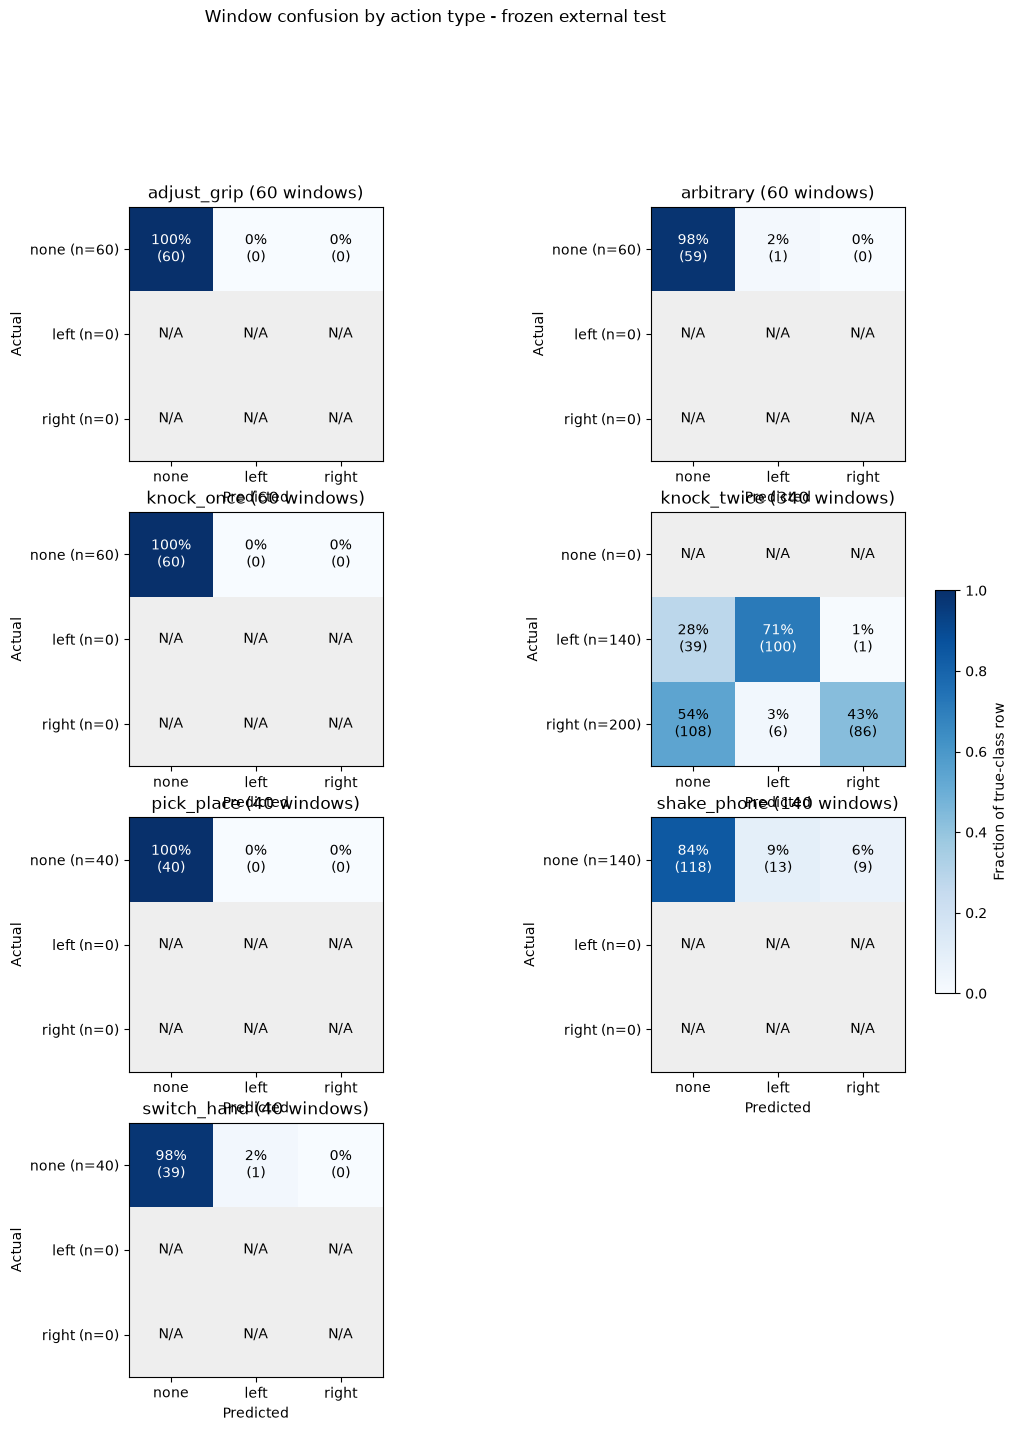

In [21]:
def render_type_confusion(ax, recording_type):
    group = type_confusion[type_confusion.recording_type == recording_type]
    counts = group['count'].to_numpy().reshape(3, 3)
    totals = counts.sum(axis=1)
    rates = np.divide(counts, totals[:, None], out=np.full((3, 3), np.nan),
                      where=totals[:, None] > 0)
    cmap = plt.get_cmap('Blues').copy()
    cmap.set_bad('#eeeeee')
    image = ax.imshow(np.ma.masked_invalid(rates), vmin=0, vmax=1, cmap=cmap)
    ax.set(title=f'{recording_type} ({int(counts.sum())} windows)', xlabel='Predicted', ylabel='Actual',
           xticks=range(3), yticks=range(3), xticklabels=CLASS_NAMES,
           yticklabels=[f'{name} (n={total})' for name, total in zip(CLASS_NAMES, totals)])
    for row in range(3):
        for col in range(3):
            text = f'{rates[row, col]:.0%}\n({counts[row, col]})' if totals[row] else 'N/A'
            ax.text(col, row, text, ha='center', va='center',
                    color='white' if totals[row] and rates[row, col] > .55 else 'black')
    return image

action_types = sorted(type_confusion.recording_type.unique())
ncols = 2
nrows = int(np.ceil(len(action_types) / ncols))
type_confusion_figure, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8*nrows), squeeze=False)
for ax, recording_type in zip(axes.flat, action_types):
    image = render_type_confusion(ax, recording_type)
for ax in list(axes.flat)[len(action_types):]:
    ax.axis('off')
type_confusion_figure.colorbar(image, ax=list(axes.flat), fraction=.02, pad=.03,
                               label='Fraction of true-class row')
type_confusion_figure.suptitle('Window confusion by action type - frozen external test', y=1.01)
plt.show()

## 6. Inspect probabilities around a test recording
Red lines are annotated second taps; green lines are **emitted** alarms. Threshold lines are different for left and right. Change `FILE` or zoom below to investigate failures.

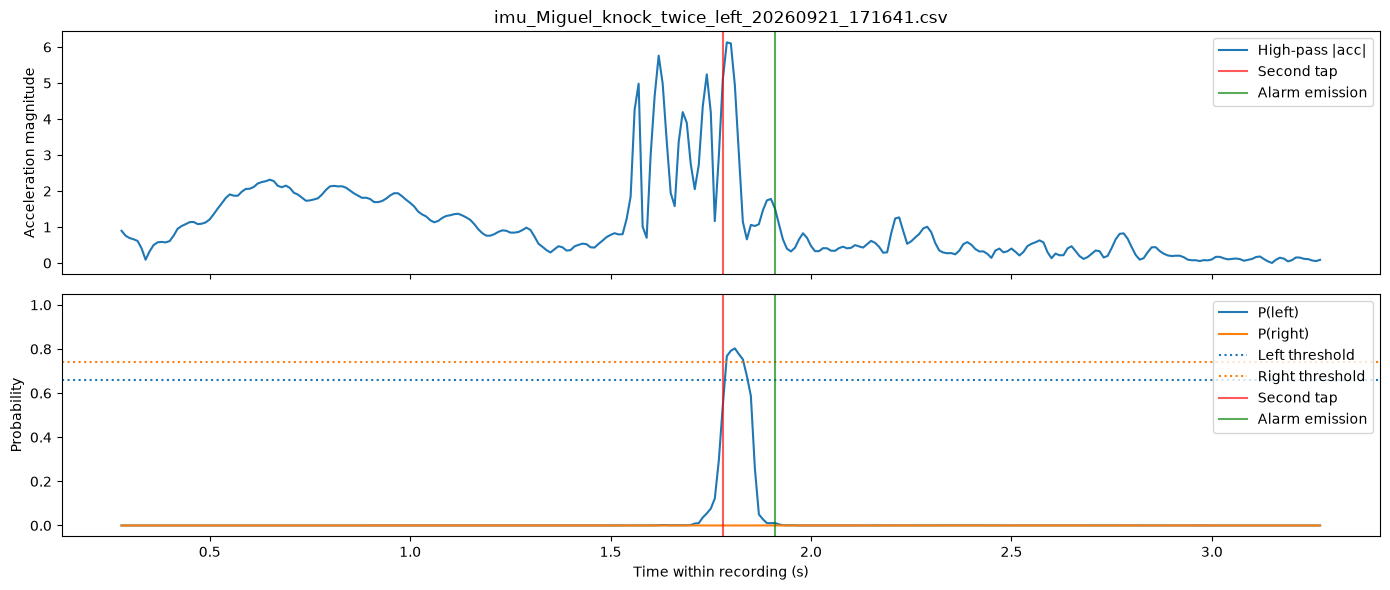

In [22]:
FILE = next(rec['file'] for rec in recordings if rec['events'])
rec = next(rec for rec in recordings if rec['file'] == FILE)
center = rec['events'][0][0] if rec['events'] else len(rec['imu'])//2
START_FRAME, END_FRAME = max(0, center - 150), min(len(rec['imu']), center + 150)
t = np.arange(START_FRAME, END_FRAME) / rec['fs']
p = probabilities[FILE][START_FRAME:END_FRAME]
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, np.linalg.norm(rec['imu'][START_FRAME:END_FRAME, :3], axis=1), label='High-pass |acc|')
axes[0].set(ylabel='Acceleration magnitude', title=FILE)
axes[1].plot(t, p[:, 1], label='P(left)')
axes[1].plot(t, p[:, 2], label='P(right)')
axes[1].axhline(LEFT_THRESHOLD, color='C0', linestyle=':', label='Left threshold')
axes[1].axhline(RIGHT_THRESHOLD, color='C1', linestyle=':', label='Right threshold')
for frame, _cls in rec['events']:
    if START_FRAME <= frame < END_FRAME:
        for ax in axes: ax.axvline(frame/rec['fs'], color='red', alpha=.65, label='Second tap')
selected_alarms = alarm_details[alarm_details.file == FILE]
for frame in selected_alarms.alarm_frame:
    if START_FRAME <= frame < END_FRAME:
        for ax in axes: ax.axvline(frame/rec['fs'], color='green', alpha=.65, label='Alarm emission')
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc='upper right')
axes[1].set(xlabel='Time within recording (s)', ylabel='Probability', ylim=(-.05, 1.05))
plt.tight_layout()
plt.show()

In [23]:
alarm_details[alarm_details.file == FILE]  # The alarms drawn above, including unmatched ones.

,file,user,type,alarm_frame,peak_frame,class_id,probability,matched,true_frame,nearest_true_delta
1,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,191,181,1,0.802813,True,178.0,13.0
2,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,465,454,1,0.819329,True,453.0,12.0
3,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,752,743,1,0.785276,True,741.0,11.0
4,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,1060,1049,1,0.778368,True,1048.0,12.0
5,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,1389,1379,1,0.774166,True,1380.0,9.0
6,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,1698,1688,1,0.799437,True,1676.0,22.0
7,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,1986,1977,1,0.822957,True,1974.0,12.0
8,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,2286,2276,1,0.761618,True,2279.0,7.0
9,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,2611,2600,1,0.766289,True,2603.0,8.0
10,imu_Miguel_knock_twice_left_20260921_171641.csv,Miguel,knock_twice,2920,2908,1,0.777354,True,2908.0,12.0


## 6. Optional export
Results record the checkpoint and test-data hashes, settings, and that this is a **frozen external test**. Saving creates a separate folder; it does not alter the training checkpoint or earlier threshold-selection CSVs.

In [24]:
SAVE_RESULTS = False
if SAVE_RESULTS:
    export_dir = RUN_DIR / 'external_test_miguel'
    export_dir.mkdir(parents=True, exist_ok=True)
    metadata = settings.assign(test_data_sha256=test_data_sha256)
    for name, table in [('settings', metadata), ('recording_audit', recording_audit),
                        ('session_exclusions_applied', applied_session_exclusions),
                        ('timestamp_gap_audit', timestamp_gap_audit),
                        ('event_summary', event_summary), ('side_summary', side_summary),
                        ('file_events', file_events), ('type_events', type_events),
                        ('user_events', user_events),
                        ('truth_events', truth_events), ('alarm_details', alarm_details),
                        ('window_summary', window_summary), ('window_predictions', window_predictions),
                        ('type_confusion', type_confusion)]:
        table.to_csv(export_dir / f'{name}.csv', index=False)
    confusion_dir = export_dir / 'action_type_confusion'
    confusion_dir.mkdir(exist_ok=True)
    type_confusion.to_csv(confusion_dir / 'type_confusion.csv', index=False)
    type_confusion_figure.savefig(export_dir / 'window_confusion_by_action_type.png', dpi=180, bbox_inches='tight')
    for recording_type in action_types:
        figure, ax = plt.subplots(figsize=(5, 4))
        image = render_type_confusion(ax, recording_type)
        figure.colorbar(image, ax=ax, fraction=.05, pad=.04, label='Fraction of true-class row')
        figure.savefig(confusion_dir / f'{recording_type}.png', dpi=180, bbox_inches='tight')
        plt.close(figure)
    print(f'Saved frozen external-test results to {export_dir}')
else:
    print('Set SAVE_RESULTS = True to export results after reviewing labels.')

Set SAVE_RESULTS = True to export results after reviewing labels.
